## Data Preprocessing 

In [2]:
# Necessary imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

#loading dataset
df = pd.read_csv("../Student Placement Dataset/full_dataset.csv")
print(df.shape)
df.head()

#dropping ID Because it is not useful for the model
df = df.drop(columns=["Student_ID"], errors='ignore')

#identifying numeric and categorical columns
numeric_columns = df.select_dtypes(include=[np.number]).columns
categorical_columns = df.select_dtypes(include=['object']).columns

# Verify the identified columns
print("Numeric Columns:", len(numeric_columns))
print(numeric_columns)
print("Categorical Columns:", len(categorical_columns))
print(categorical_columns)

# Checking the distribution of the target variable for Classification Task 1
df['Placement_Status'].value_counts(normalize=True) * 100

(50000, 15)
Numeric Columns: 10
Index(['Age', 'CGPA', 'Internships', 'Projects', 'Coding_Skills',
       'Communication_Skills', 'Aptitude_Test_Score', 'Soft_Skills_Rating',
       'Certifications', 'Backlogs'],
      dtype='str')
Categorical Columns: 4
Index(['Gender', 'Degree', 'Branch', 'Placement_Status'], dtype='str')


C:\Users\ncast\AppData\Local\Temp\ipykernel_28080\4210746141.py:20: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include=['object']).columns


Placement_Status
Not Placed    63.752
Placed        36.248
Name: proportion, dtype: float64

In [3]:
# Getting Test and Train Split for Task 1: Placement Status Classification
X_task1 = df.drop(columns=["Placement_Status"])
y_task1 = df["Placement_Status"]

# Identify feature types AFTER dropping targets
numeric_columns_task1 = X_task1.select_dtypes(include=np.number).columns
categorical_columns_task1 = X_task1.select_dtypes(include="object").columns

# Preprocessor for Task 1
preprocessor_task1 = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_columns_task1),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_columns_task1)
    ]
)

# Train Test Split
X_train_task1, X_test_task1, y_train_task1, y_test_task1 = train_test_split(
    X_task1,
    y_task1,
    test_size=0.3,
    random_state=42,
    stratify=y_task1
)

# Fit ONLY on train
X_train_task1 = preprocessor_task1.fit_transform(X_train_task1)
X_test_task1 = preprocessor_task1.transform(X_test_task1)

# Final Ready-to-Use Data
print("TASK 1 Ready Shapes:")
print(X_train_task1.shape, X_test_task1.shape)

C:\Users\ncast\AppData\Local\Temp\ipykernel_28080\2841335292.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns_task1 = X_task1.select_dtypes(include="object").columns


TASK 1 Ready Shapes:
(35000, 18) (15000, 18)


## Cluster Analysis Using Gaussian Mixture Model (GMM)

### Top Important Features Based on Random Forest Analysis

In [4]:
# Select top features based on importance
top_features_list = [
    "Communication_Skills",
    "Backlogs",
    "CGPA",
    "Coding_Skills",
    "Projects",
    "Certifications",
    "Aptitude_Test_Score"
]

# Subset dataset
X_cluster = df[top_features_list]

# Scale features (VERY IMPORTANT for GMM)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

### Determining Optimal Number of Clusters

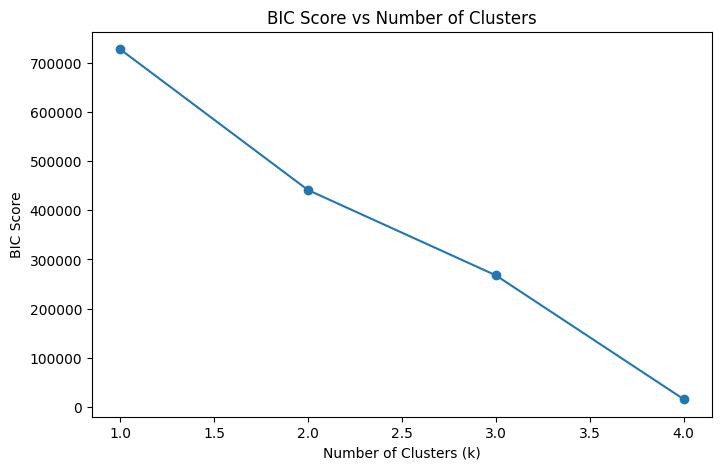

Optimal number of clusters: 4


In [14]:
# Determining Optimal Number of Clusters 
# Code: Find Optimal k

from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt

bic_scores = []
k_range = range(1, 5)

for k in k_range:
    gmm = GaussianMixture(n_components=k, random_state=42)
    gmm.fit(X_scaled)
    bic_scores.append(gmm.bic(X_scaled))

# Plot BIC
plt.figure(figsize=(8,5))
plt.plot(k_range, bic_scores, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("BIC Score")
plt.title("BIC Score vs Number of Clusters")
plt.show()

# Best k
optimal_k = k_range[bic_scores.index(min(bic_scores))]
print("Optimal number of clusters:", optimal_k)

To determine the optimal number of clusters for the Gaussian Mixture Model, the Bayesian Information Criterion (BIC) was evaluated across a range of cluster values from 1 to 4. This restricted range was intentionally chosen based on domain understanding, as it is reasonable to expect only a small number of distinct student profiles influencing job placement outcomes (e.g., high-performing, average, and at-risk students). The BIC scores decreased consistently as the number of clusters increased, with the lowest value observed at k = 4, indicating the best balance between model fit and complexity within the tested range. Although the downward trend suggests that additional clusters may continue to improve model fit, selecting four clusters aligns well with the practical goal of maintaining interpretability while still capturing meaningful variation in student characteristics. Therefore, k = 4 was selected as the optimal number of clusters for the Gaussian Mixture Model in this analysis.

### Apply Gaussian Mixture Model

#### Train GMM

In [6]:
# Apply Gaussian Mixture Model
# Code: Train GMM

# Train final model
gmm_final = GaussianMixture(n_components=optimal_k, random_state=42)
gmm_final.fit(X_scaled)

# Assign clusters
cluster_labels = gmm_final.predict(X_scaled)

# Add to dataframe
df["GMM_Cluster"] = cluster_labels

# Probabilities (soft clustering insight)
cluster_probs = gmm_final.predict_proba(X_scaled)

### Cluster Evaluation

In [7]:
# Cluster Evaluation 
# Code: Silhouette Score

from sklearn.metrics import silhouette_score

sil_score = silhouette_score(X_scaled, cluster_labels)
print("Silhouette Score:", sil_score)

Silhouette Score: 0.16356260260796385


Cluster quality was evaluated using the Silhouette Score, which measures how well observations are grouped within their assigned clusters compared to other clusters. The Gaussian Mixture Model produced a silhouette score of approximately 0.16, indicating modest separation between clusters. This suggests that while some cluster structure is present, there is still a noticeable degree of overlap among student groups. This result is expected given the nature of the dataset, as student performance and placement readiness tend to exist along a continuum rather than in sharply defined categories. Additionally, because the Gaussian Mixture Model uses probabilistic (soft) clustering, it is inherently designed to handle overlapping data points more effectively than hard clustering methods. Therefore, despite the relatively low silhouette score, the model still provides meaningful insights into underlying student segments and captures the gradual differences in placement readiness across the population.

### Cluster Distribution vs Placement

In [ ]:
placement_distribution = pd.crosstab(df["GMM_Cluster"], df["Placement_Status"], normalize="index") * 100
print(placement_distribution)

Placement_Status  Not Placed     Placed
GMM_Cluster                            
0                  98.285752   1.714248
1                  32.089304  67.910696
2                  64.584590  35.415410
3                  29.690049  70.309951


The relationship between cluster membership and placement outcomes was analyzed by examining the distribution of Placement_Status within each Gaussian Mixture Model cluster. The results show clear and meaningful differences across clusters, indicating that the model successfully identified distinct student segments. Clusters 1 and 3 demonstrate high placement rates (approximately 67.9% and 70.3% placed, respectively), suggesting these groups represent well-prepared students with strong academic and communication profiles. In contrast, Cluster 0 exhibits an extremely low placement rate (only 1.7% placed), identifying a group of students who are at significant risk of not securing employment. Cluster 2 shows a more moderate outcome (35.4% placed), representing students who may be borderline in terms of placement readiness. These differences highlight how key features—such as communication skills, CGPA, and backlogs—contribute to separating students into meaningful performance-based groups. Overall, the clustering results provide valuable insight into varying levels of student preparedness and demonstrate the effectiveness of the Gaussian Mixture Model in uncovering patterns related to placement success.

### PCA Visualization

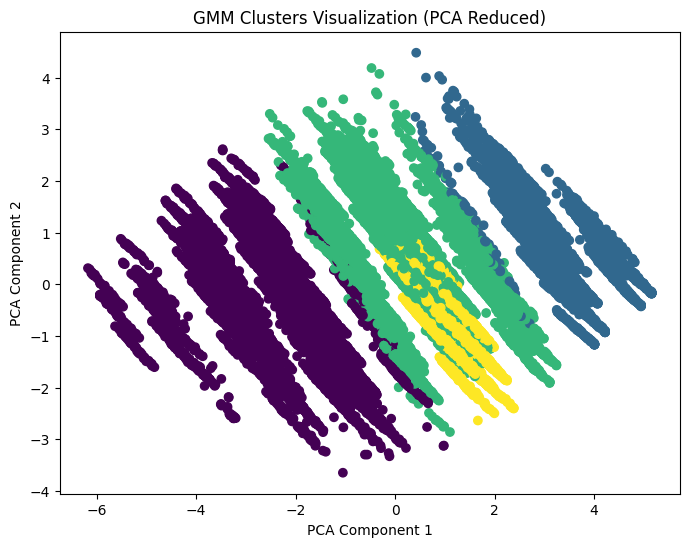

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=cluster_labels)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("GMM Clusters Visualization (PCA Reduced)")
plt.show()

To better understand the structure of the clusters identified by the Gaussian Mixture Model, the high-dimensional feature space was reduced to two principal components using Principal Component Analysis (PCA) and visualized in a scatter plot. The resulting visualization shows clusters forming along diagonal bands, indicating strong correlations among the selected features such as communication skills, CGPA, and technical experience. While distinct groupings can be observed, there is also noticeable overlap between clusters, which aligns with the relatively low silhouette score. This overlap suggests that student characteristics do not form sharply separated groups, but rather exist along a continuum of performance and readiness. The visualization reinforces the advantage of using GMM, as it captures these soft boundaries and allows for more flexible cluster assignments compared to rigid clustering methods.

### Conclusion on Gaussian Mixture Model Clustering Method

Overall, the Gaussian Mixture Model proved to be an effective method for uncovering underlying student segments within the dataset. Although the clusters were not perfectly separated, the model successfully identified meaningful groupings that correspond to varying levels of placement success, including high-performing, moderate, and at-risk student profiles. The probabilistic nature of GMM allowed for a more realistic representation of the data, capturing the inherent overlap between student characteristics. These insights are valuable for both educational institutions and students, as they highlight key factors influencing placement outcomes and provide a foundation for targeted interventions. In this context, GMM offered a nuanced and interpretable approach to understanding student readiness beyond traditional classification methods.